# Notebook 1 – Data Preprocessing

This notebook prepares the datasets used throughout the dissertation.

Outputs:
- `women_baseline.parquet`
- `women_subgroup.parquet`
- `immigration_baseline.parquet`


In [ ]:
pip install emoji

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 11.3 MB/s eta 0:00:00


In [ ]:
# ============================================================
# Dissertation: Perspective-Aware Hate Speech Detection
# Notebook 1 - Data Preprocessing
# ============================================================

import re
import html
from collections import Counter

import emoji
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import entropy

# ------------------------------------------------------------
# Display options
# ------------------------------------------------------------

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 200)

plt.style.use("ggplot")

RANDOM_STATE = 42

In [ ]:
# ------------------------------------------------------------
# Load dataset
# ------------------------------------------------------------

DATA_PATH = "/content/mhs_main_experiment_annotations_with_split.csv"

raw_df = pd.read_csv(DATA_PATH)

print("=" * 60)
print("Dataset loaded successfully")
print("=" * 60)

print(f"Rows    : {len(raw_df):,}")
print(f"Columns : {raw_df.shape[1]}")

Dataset loaded successfully
Rows    : 49,433
Columns : 53


In [ ]:
raw_df.head()

,comment_id,annotator_id,sentiment,respect,insult,humiliate,status,dehumanize,violence,genocide,attack_defend,hatespeech,annotator_gender,annotator_trans,annotator_gender_men,annotator_gender_women,annotator_gender_non_binary,annotator_gender_prefer_not_to_say,annotator_gender_self_describe,annotator_transgender,annotator_cisgender,annotator_transgender_prefer_not_to_say,annotator_ideology,annotator_ideology_extremeley_conservative,annotator_ideology_conservative,annotator_ideology_slightly_conservative,annotator_ideology_neutral,annotator_ideology_slightly_liberal,annotator_ideology_liberal,annotator_ideology_extremeley_liberal,annotator_ideology_no_opinion,target_gender,target_gender_men,target_gender_non_binary,target_gender_transgender_men,target_gender_transgender_unspecified,target_gender_transgender_women,target_gender_women,target_gender_other,target_origin,target_origin_immigrant,target_origin_migrant_worker,target_origin_specific_country,target_origin_undocumented,target_origin_other,text_original,text_clean,is_women_targeted,is_immigrant_targeted,annotator_gender_group,annotator_ideology_group,target_type,split
0,47101,3379,4.0,4.0,4.0,4.0,4.0,4.0,0.0,0.0,4.0,2.0,male,no,1,0,0,0,0,False,True,False,slightly_conservative,0,0,1,0,0,0,0,0,False,0,0,0,0,0,0,0,True,1,0,0,0,0,"Question: These 4 broads who criticize America, what country did they flee to get here? And now they want to make OUR America like THEIR former HELL HOLE. I don't think so!!!!!!!!!! Let them expl...","Question: These 4 broads who criticize America, what country did they flee to get here? And now they want to make OUR America like THEIR former HELL HOLE. I don't think so!!!!!!!!!! Let them expla...",0,1,men,slightly_conservative,immigrant_only,validation
1,43625,7365,2.0,3.0,2.0,1.0,2.0,0.0,0.0,0.0,3.0,0.0,male,no,1,0,0,0,0,False,True,False,neutral,0,0,0,1,0,0,0,0,False,0,0,0,0,0,0,0,True,0,0,0,1,0,It is about time for all illegals to go back to their country of origin and keep our freeway open and prevent heavy traffic.,It is about time for all illegals to go back to their country of origin and keep our freeway open and prevent heavy traffic.,0,1,men,neutral,immigrant_only,train
2,12538,488,4.0,4.0,4.0,4.0,4.0,4.0,4.0,1.0,3.0,2.0,female,no,0,1,0,0,0,False,True,False,neutral,0,0,0,1,0,0,0,0,True,0,0,0,0,0,1,0,False,0,0,0,0,0,For starters bend over the one in pink and kick that ass and pussy to get a taste until she's begging for a dick inside her.,For starters bend over the one in pink and kick that ass and pussy to get a taste until she's begging for a dick inside her.,1,0,women,neutral,women_only,test
3,40171,10363,4.0,4.0,4.0,3.0,3.0,3.0,0.0,1.0,1.0,0.0,female,no,0,1,0,0,0,False,True,False,slightly_conservative,0,0,1,0,0,0,0,0,True,0,0,0,0,0,1,0,False,0,0,0,0,0,"OMG! The EGO's of these young, young, inexperienced women display are remarkable! So self absorbed - so, so proud of the mistakes their constituents all made in giving them a bit of power. They'l...","OMG! The EGO's of these young, young, inexperienced women display are remarkable! So self absorbed - so, so proud of the mistakes their constituents all made in giving them a bit of power. They'll...",1,0,women,slightly_conservative,women_only,train
4,1006,10615,4.0,4.0,4.0,4.0,4.0,4.0,4.0,0.0,4.0,2.0,female,no,0,1,0,0,0,False,True,False,extremely_liberal,0,0,0,0,0,0,0,0,True,0,0,0,0,0,1,0,False,0,0,0,0,0,"Worthless whore, these tits with look nice with bite marks and cum","Worthless whore, these tits with look nice with bite marks and cum",1,0,women,extremely_liberal,women_only,train


In [ ]:
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49433 entries, 0 to 49432
Data columns (total 53 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   comment_id                                  49433 non-null  int64  
 1   annotator_id                                49433 non-null  int64  
 2   sentiment                                   49433 non-null  float64
 3   respect                                     49433 non-null  float64
 4   insult                                      49433 non-null  float64
 5   humiliate                                   49433 non-null  float64
 6   status                                      49433 non-null  float64
 7   dehumanize                                  49433 non-null  float64
 8   violence                                    49433 non-null  float64
 9   genocide                                    49433 non-null  float64
 10  attack_def

In [ ]:
raw_df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
comment_id,49433.0,NaN,NaN,NaN,24463.86681,12900.555124,6.0,18140.0,20057.0,34564.0,50070.0
annotator_id,49433.0,NaN,NaN,NaN,5564.128133,3232.176102,1.0,2706.0,5617.0,8355.0,11142.0
sentiment,49433.0,NaN,NaN,NaN,3.075537,1.155687,0.0,3.0,3.0,4.0,4.0
respect,49433.0,NaN,NaN,NaN,2.967957,1.242157,0.0,2.0,3.0,4.0,4.0
insult,49433.0,NaN,NaN,NaN,2.69403,1.323374,0.0,2.0,3.0,4.0,4.0
humiliate,49433.0,NaN,NaN,NaN,2.412194,1.325344,0.0,1.0,3.0,3.0,4.0
status,49433.0,NaN,NaN,NaN,2.751684,0.895211,0.0,2.0,3.0,3.0,4.0
dehumanize,49433.0,NaN,NaN,NaN,1.975988,1.393757,0.0,1.0,2.0,3.0,4.0
violence,49433.0,NaN,NaN,NaN,1.077276,1.318117,0.0,0.0,1.0,2.0,4.0
genocide,49433.0,NaN,NaN,NaN,0.596403,1.073776,0.0,0.0,0.0,1.0,4.0


In [ ]:
missing = (
    raw_df
    .isna()
    .sum()
    .sort_values(ascending=False)
    .rename("Missing Values")
)

missing.to_frame()

,Missing Values
annotator_ideology,17
annotator_id,0
sentiment,0
respect,0
comment_id,0
humiliate,0
status,0
dehumanize,0
violence,0
genocide,0


In [ ]:
important_columns = [
    "comment_id",
    "text_clean",
    "split",
    "hatespeech",
    "annotator_gender_group",
    "annotator_ideology_group",
    "is_women_targeted",
    "is_immigrant_targeted",
]

raw_df[important_columns].head()

,comment_id,text_clean,split,hatespeech,annotator_gender_group,annotator_ideology_group,is_women_targeted,is_immigrant_targeted
0,47101,"Question: These 4 broads who criticize America, what country did they flee to get here? And now they want to make OUR America like THEIR former HELL HOLE. I don't think so!!!!!!!!!! Let them expla...",validation,2.0,men,slightly_conservative,0,1
1,43625,It is about time for all illegals to go back to their country of origin and keep our freeway open and prevent heavy traffic.,train,0.0,men,neutral,0,1
2,12538,For starters bend over the one in pink and kick that ass and pussy to get a taste until she's begging for a dick inside her.,test,2.0,women,neutral,1,0
3,40171,"OMG! The EGO's of these young, young, inexperienced women display are remarkable! So self absorbed - so, so proud of the mistakes their constituents all made in giving them a bit of power. They'll...",train,0.0,women,slightly_conservative,1,0
4,1006,"Worthless whore, these tits with look nice with bite marks and cum",train,2.0,women,extremely_liberal,1,0


In [ ]:
(
    raw_df["hatespeech"]
    .value_counts()
    .sort_index()
)

,count
hatespeech,
0.0,29951
1.0,3582
2.0,15900


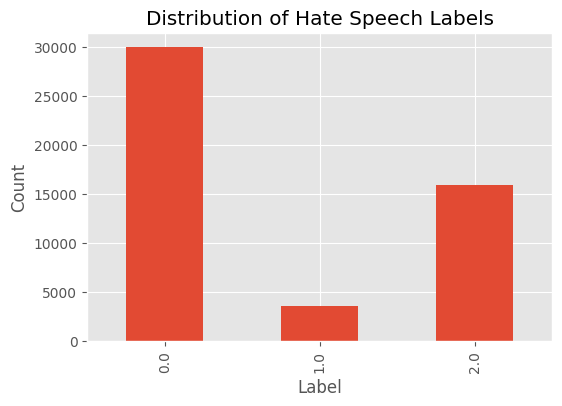

In [ ]:
plt.figure(figsize=(6,4))

raw_df["hatespeech"].value_counts().sort_index().plot(
    kind="bar"
)

plt.title("Distribution of Hate Speech Labels")
plt.xlabel("Label")
plt.ylabel("Count")

plt.show()

In [ ]:
raw_df["split"].value_counts()

,count
split,
train,34413
test,7713
validation,7307


In [ ]:
raw_df["annotator_gender_group"].value_counts(dropna=False)

,count
annotator_gender_group,
women,27716
men,21112
non_binary,362
prefer_not_to_say,189
self_describe,54


In [ ]:
raw_df["annotator_ideology_group"].value_counts(dropna=False)

,count
annotator_ideology_group,
liberal,12437
neutral,8222
slightly_liberal,7844
extremely_liberal,6667
conservative,5772
slightly_conservative,5418
extremely_conservative,1655
no_opinion,1401
unknown,17


In [ ]:
print("Women targeted comments:")
print(raw_df["is_women_targeted"].value_counts())

print()

print("Immigration targeted comments:")
print(raw_df["is_immigrant_targeted"].value_counts())

Women targeted comments:
is_women_targeted
1    27889
0    21544
Name: count, dtype: int64

Immigration targeted comments:
is_immigrant_targeted
0    26905
1    22528
Name: count, dtype: int64


In [ ]:
import unicodedata

In [ ]:
# ============================================================
# Text Cleaning
# ============================================================

URL_PATTERN = re.compile(r"https?://\S+|www\.\S+")
MENTION_PATTERN = re.compile(r"@\w+")


def clean_text(text: str) -> str:
    """
    Performs light preprocessing suitable for transformer models.

    Steps
    -----
    1. Remove URLs
    2. Remove user mentions
    3. Remove emojis
    4. Decode HTML entities
    5. Normalize unicode
    6. Remove repeated whitespace

    Parameters
    ----------
    text : str

    Returns
    -------
    str
    """

    if pd.isna(text):
        return ""

    text = str(text)

    # HTML entities
    text = html.unescape(text)

    # Unicode normalization
    text = unicodedata.normalize("NFKC", text)

    # URLs
    text = URL_PATTERN.sub("", text)

    # Mentions
    text = MENTION_PATTERN.sub("", text)

    # Emojis
    text = emoji.replace_emoji(text, replace="")

    # Remove the '#' but keep the word
    text = text.replace("#", "")

    # Remove extra whitespace
    text = re.sub(r"\s+", " ", text)

    return text.strip()

In [ ]:
working_df = raw_df.copy()

working_df["processed_text"] = (
    working_df["text_clean"]
    .fillna("")
    .apply(clean_text)
)

In [ ]:
sample = (
    working_df[
        ["text_clean", "processed_text"]
    ]
    .sample(20, random_state=42)
)

for idx, row in sample.iterrows():

    print("="*80)

    print("ORIGINAL\n")
    print(row["text_clean"])

    print()

    print("CLEANED\n")
    print(row["processed_text"])

    print("\n")

ORIGINAL

I'll kick that hoe in her chest

CLEANED

I'll kick that hoe in her chest


ORIGINAL

Females do, in fact, have one more hole. Stay in school y'all. Also, there are holes in your tear ducts. Not to mention pores all over your body. So, we all have a shit load of holes. However, if a man and woman have equal number of pores....she will still have one more hole than the man has.

CLEANED

Females do, in fact, have one more hole. Stay in school y'all. Also, there are holes in your tear ducts. Not to mention pores all over your body. So, we all have a shit load of holes. However, if a man and woman have equal number of pores....she will still have one more hole than the man has.


ORIGINAL

happy pride month i'm gay URL

CLEANED

happy pride month i'm gay URL


ORIGINAL

Uh. Yes it does. Unless your calling the Middle East uncivilized? Is that what you're saying. Cause that some people ethnocentric shit.

CLEANED

Uh. Yes it does. Unless your calling the Middle East uncivilized? 

In [ ]:
empty_comments = (
    working_df["processed_text"]
    .str.len()
    .eq(0)
    .sum()
)

print(f"Empty comments after cleaning: {empty_comments:,}")

Empty comments after cleaning: 0


In [ ]:
working_df["original_length"] = (
    working_df["text_clean"]
    .str.len()
)

working_df["processed_length"] = (
    working_df["processed_text"]
    .str.len()
)

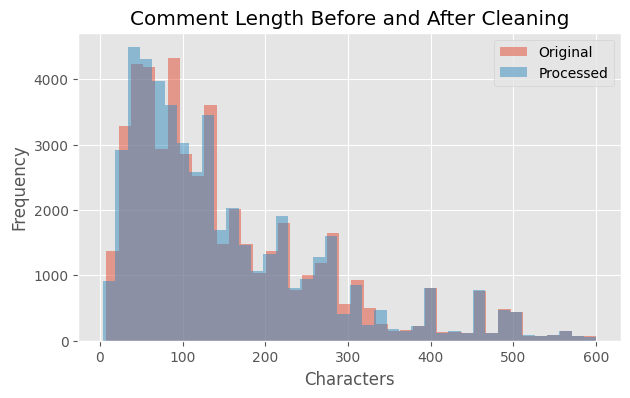

In [ ]:
plt.figure(figsize=(7,4))

plt.hist(
    working_df["original_length"],
    bins=40,
    alpha=0.5,
    label="Original"
)

plt.hist(
    working_df["processed_length"],
    bins=40,
    alpha=0.5,
    label="Processed"
)

plt.legend()

plt.title("Comment Length Before and After Cleaning")

plt.xlabel("Characters")

plt.ylabel("Frequency")

plt.show()

In [ ]:
assert working_df["processed_text"].isna().sum() == 0

assert (
    working_df["processed_text"]
    .str.strip()
    .eq("")
    .sum()
) == 0

In [ ]:
LABELS = [0, 1, 2]


def compute_distribution(labels):
    """
    Converts a sequence of hate speech labels into
    counts and probability distribution.
    """

    labels = np.asarray(labels)

    counts = np.array(
        [(labels == label).sum() for label in LABELS],
        dtype=np.float32,
    )

    probabilities = counts / counts.sum()

    return counts, probabilities

In [ ]:
compute_distribution([2,2,1,0,2])

(array([1., 1., 3.], dtype=float32), array([0.2, 0.2, 0.6], dtype=float32))

In [ ]:
def compute_entropy(distribution):
    """
    Computes Shannon entropy of a probability distribution.
    """

    return entropy(distribution, base=2)

In [ ]:
def majority_vote(counts):
    """
    Returns the majority hate speech label.
    """

    return int(np.argmax(counts))

In [ ]:
compute_entropy([0.33,0.33,0.34])

np.float64(1.58481870497303)

In [ ]:
def expected_label(distribution):
    """
    Computes the expected hate speech score.
    """

    labels = np.arange(len(distribution))

    return float(np.dot(labels, distribution))

In [ ]:
expected_label([0.2,0.3,0.5])

1.3

In [ ]:
LABELS = [0, 1, 2]


def aggregate_comment(comment_df: pd.DataFrame,
                      subgroup_column: str) -> dict:
    """
    Aggregate all annotations belonging to a single comment.

    Parameters
    ----------
    comment_df : pd.DataFrame
        DataFrame containing all annotation rows for one comment.

    subgroup_column : str
        Annotator subgroup column.
        Examples:
            - annotator_gender_group
            - annotator_ideology_group

    Returns
    -------
    dict
        Comment-level record containing overall and subgroup statistics.
    """

    # ---------- Basic information ----------
    comment_id = comment_df["comment_id"].iloc[0]
    text = comment_df["processed_text"].iloc[0]
    split = comment_df["split"].iloc[0]

    # ---------- Overall label distribution ----------
    labels = comment_df["hatespeech"].astype(int).to_numpy()

    overall_counts, overall_distribution = compute_distribution(labels)

    # ---------- Overall statistics ----------
    entropy_value = compute_entropy(overall_distribution)

    majority = majority_vote(overall_counts)

    expected = expected_label(overall_distribution)

    # ---------- Subgroup statistics ----------
    subgroup_counts = {}
    subgroup_label_counts = {}
    subgroup_distributions = {}

    for subgroup, subgroup_df in comment_df.groupby(subgroup_column):

        subgroup_labels = subgroup_df["hatespeech"].astype(int).to_numpy()

        counts, distribution = compute_distribution(subgroup_labels)

        subgroup_counts[subgroup] = len(subgroup_df)

        subgroup_label_counts[subgroup] = counts.tolist()

        subgroup_distributions[subgroup] = distribution.tolist()

    return {

        "comment_id": comment_id,

        "text": text,

        "split": split,

        "num_annotations": len(comment_df),

        "overall_counts": overall_counts.tolist(),

        "overall_distribution": overall_distribution.tolist(),

        "entropy": entropy_value,

        "majority_label": majority,

        "expected_label": expected,

        "subgroup_counts": subgroup_counts,

        "subgroup_label_counts": subgroup_label_counts,

        "subgroup_distributions": subgroup_distributions,

    }

In [ ]:
LABELS = [0, 1, 2]


def aggregate_comment(comment_df: pd.DataFrame,
                      subgroup_column: str) -> dict:
    """
    Aggregate all annotations belonging to a single comment.

    Parameters
    ----------
    comment_df : pd.DataFrame
        DataFrame containing all annotation rows for one comment.

    subgroup_column : str
        Annotator subgroup column.
        Examples:
            - annotator_gender_group
            - annotator_ideology_group

    Returns
    -------
    dict
        Comment-level record containing overall and subgroup statistics.
    """

    # ---------- Basic information ----------
    comment_id = comment_df["comment_id"].iloc[0]
    text = comment_df["processed_text"].iloc[0]
    split = comment_df["split"].iloc[0]

    # ---------- Overall label distribution ----------
    labels = comment_df["hatespeech"].astype(int).to_numpy()

    overall_counts, overall_distribution = compute_distribution(labels)

    # ---------- Overall statistics ----------
    entropy_value = compute_entropy(overall_distribution)

    majority = majority_vote(overall_counts)

    expected = expected_label(overall_distribution)

    # ---------- Subgroup statistics ----------
    subgroup_counts = {}
    subgroup_label_counts = {}
    subgroup_distributions = {}

    for subgroup, subgroup_df in comment_df.groupby(subgroup_column):

        subgroup_labels = subgroup_df["hatespeech"].astype(int).to_numpy()

        counts, distribution = compute_distribution(subgroup_labels)

        subgroup_counts[subgroup] = len(subgroup_df)

        subgroup_label_counts[subgroup] = counts.tolist()

        subgroup_distributions[subgroup] = distribution.tolist()

    return {

        "comment_id": comment_id,

        "text": text,

        "split": split,

        "num_annotations": len(comment_df),

        "overall_counts": overall_counts.tolist(),

        "overall_distribution": overall_distribution.tolist(),

        "entropy": entropy_value,

        "majority_label": majority,

        "expected_label": expected,

        "subgroup_counts": subgroup_counts,

        "subgroup_label_counts": subgroup_label_counts,

        "subgroup_distributions": subgroup_distributions,

    }

In [ ]:
women_annotations = working_df[
    working_df["is_women_targeted"] == 1
]

women_processed = pd.DataFrame(
    [
        aggregate_comment(group, "annotator_gender_group")
        for _, group in women_annotations.groupby("comment_id")
    ]
)

print(women_processed.shape)
women_processed.head()

(11983, 12)


,comment_id,text,split,num_annotations,overall_counts,overall_distribution,entropy,majority_label,expected_label,subgroup_counts,subgroup_label_counts,subgroup_distributions
0,6,First off you look cool as fuck! Anyway if we were in the bedroom I think I'd cream your ass then make you suck my cock clean like a whore ;),train,2,"[2.0, 0.0, 0.0]","[1.0, 0.0, 0.0]",0.0,0,0.0,"{'men': 1, 'women': 1}","{'men': [1.0, 0.0, 0.0], 'women': [1.0, 0.0, 0.0]}","{'men': [1.0, 0.0, 0.0], 'women': [1.0, 0.0, 0.0]}"
1,11,"eat my fuck, bitch",validation,2,"[0.0, 1.0, 1.0]","[0.0, 0.5, 0.5]",1.0,1,1.5,"{'men': 1, 'women': 1}","{'men': [0.0, 0.0, 1.0], 'women': [0.0, 1.0, 0.0]}","{'men': [0.0, 0.0, 1.0], 'women': [0.0, 1.0, 0.0]}"
2,12,She ugly anyways,train,2,"[1.0, 0.0, 1.0]","[0.5, 0.0, 0.5]",1.0,0,1.0,{'women': 2},"{'women': [1.0, 0.0, 1.0]}","{'women': [0.5, 0.0, 0.5]}"
3,19,Won't happen. Birth rates are down. Women want full control of reproduction. Feminists have very powerful lobbying. There's no money in it for big pharma. Men would be far more diligent and discip...,train,2,"[2.0, 0.0, 0.0]","[1.0, 0.0, 0.0]",0.0,0,0.0,{'men': 2},"{'men': [2.0, 0.0, 0.0]}","{'men': [1.0, 0.0, 0.0]}"
4,22,The guys are one thing but then you have a woman there making one of the worst comments. I say rape them all with a cactus and say God willed it,train,2,"[1.0, 0.0, 1.0]","[0.5, 0.0, 0.5]",1.0,0,1.0,{'men': 2},"{'men': [1.0, 0.0, 1.0]}","{'men': [0.5, 0.0, 0.5]}"


In [ ]:
immigration_annotations = working_df[
    working_df["is_immigrant_targeted"] == 1
]

immigration_processed = pd.DataFrame(
    [
        aggregate_comment(group, "annotator_ideology_group")
        for _, group in immigration_annotations.groupby("comment_id")
    ]
)

print(immigration_processed.shape)
immigration_processed.head()

(8621, 12)


,comment_id,text,split,num_annotations,overall_counts,overall_distribution,entropy,majority_label,expected_label,subgroup_counts,subgroup_label_counts,subgroup_distributions
0,7,\*points to posters asking for palestinian rights and freedom\* theyre antisemetic and want to kill all the jews and dont acknowledge our right to exist ​ cant wait for this prick to die and go st...,test,2,"[1.0, 0.0, 1.0]","[0.5, 0.0, 0.5]",1.000000,0,1.000000,"{'extremely_liberal': 1, 'liberal': 1}","{'extremely_liberal': [1.0, 0.0, 0.0], 'liberal': [0.0, 0.0, 1.0]}","{'extremely_liberal': [1.0, 0.0, 0.0], 'liberal': [0.0, 0.0, 1.0]}"
1,10,"They'll come back in your plan, also. Plus we pay to jail them for 2 years. With my plan, we jail them after they come back. And deport them again. It really doesn't matter either way until we're ...",train,3,"[1.0, 0.0, 2.0]","[0.3333333432674408, 0.0, 0.6666666865348816]",0.918296,2,1.333333,"{'liberal': 1, 'neutral': 1, 'slightly_conservative': 1}","{'liberal': [0.0, 0.0, 1.0], 'neutral': [0.0, 0.0, 1.0], 'slightly_conservative': [1.0, 0.0, 0.0]}","{'liberal': [0.0, 0.0, 1.0], 'neutral': [0.0, 0.0, 1.0], 'slightly_conservative': [1.0, 0.0, 0.0]}"
2,13,Do they realize that a random Japanese person isn't going to randomly join a religion they barely know exists based on seeing a book from it in their hotel room?,train,2,"[2.0, 0.0, 0.0]","[1.0, 0.0, 0.0]",0.000000,0,0.000000,"{'extremely_liberal': 1, 'liberal': 1}","{'extremely_liberal': [1.0, 0.0, 0.0], 'liberal': [1.0, 0.0, 0.0]}","{'extremely_liberal': [1.0, 0.0, 0.0], 'liberal': [1.0, 0.0, 0.0]}"
3,23,"Build the wall, and put these spics in prison with the nogs.",validation,1,"[0.0, 0.0, 1.0]","[0.0, 0.0, 1.0]",0.000000,2,2.000000,{'slightly_conservative': 1},"{'slightly_conservative': [0.0, 0.0, 1.0]}","{'slightly_conservative': [0.0, 0.0, 1.0]}"
4,24,Love from an Indian from USA.,train,1,"[1.0, 0.0, 0.0]","[1.0, 0.0, 0.0]",0.000000,0,0.000000,{'conservative': 1},"{'conservative': [1.0, 0.0, 0.0]}","{'conservative': [1.0, 0.0, 0.0]}"


In [ ]:
def has_required_subgroups(subgroup_counts: dict, required_groups: list[str]) -> bool:
    """
    Checks whether a comment has at least one annotation from every required subgroup.
    """
    return all(subgroup_counts.get(group, 0) >= 1 for group in required_groups)


def has_min_distinct_subgroups(subgroup_counts: dict, min_groups: int = 2) -> bool:
    """
    Checks whether a comment has annotations from at least `min_groups` different subgroups.
    """
    active_groups = [
        group for group, count in subgroup_counts.items()
        if count >= 1
    ]
    return len(active_groups) >= min_groups

In [ ]:
VALID_GENDER_GROUPS = ["women", "men", "non_binary"]

women_experiment = women_processed[
    women_processed["subgroup_counts"].apply(
        lambda d: sum(d.get(group, 0) >= 1 for group in VALID_GENDER_GROUPS) >= 2
    )
].copy()

print(f"Women processed comments: {len(women_processed):,}")
print(f"Women experiment comments: {len(women_experiment):,}")

women_experiment.head()

Women processed comments: 11,983
Women experiment comments: 3,953


,comment_id,text,split,num_annotations,overall_counts,overall_distribution,entropy,majority_label,expected_label,subgroup_counts,subgroup_label_counts,subgroup_distributions
0,6,First off you look cool as fuck! Anyway if we were in the bedroom I think I'd cream your ass then make you suck my cock clean like a whore ;),train,2,"[2.0, 0.0, 0.0]","[1.0, 0.0, 0.0]",0.000000,0,0.000000,"{'men': 1, 'women': 1}","{'men': [1.0, 0.0, 0.0], 'women': [1.0, 0.0, 0.0]}","{'men': [1.0, 0.0, 0.0], 'women': [1.0, 0.0, 0.0]}"
1,11,"eat my fuck, bitch",validation,2,"[0.0, 1.0, 1.0]","[0.0, 0.5, 0.5]",1.000000,1,1.500000,"{'men': 1, 'women': 1}","{'men': [0.0, 0.0, 1.0], 'women': [0.0, 1.0, 0.0]}","{'men': [0.0, 0.0, 1.0], 'women': [0.0, 1.0, 0.0]}"
5,26,I'd love to rip those panties off and shove my fat cock in her ass.,train,3,"[2.0, 0.0, 1.0]","[0.6666666865348816, 0.0, 0.3333333432674408]",0.918296,0,0.666667,"{'men': 2, 'women': 1}","{'men': [1.0, 0.0, 1.0], 'women': [1.0, 0.0, 0.0]}","{'men': [0.5, 0.0, 0.5], 'women': [1.0, 0.0, 0.0]}"
10,44,"I mean, by this logic they want to ban sex, right? According to them, a woman having an orgasm means her egg(s) shoot out of her vagina like a fucking cannon. So what happens when a woman has sex ...",train,2,"[2.0, 0.0, 0.0]","[1.0, 0.0, 0.0]",0.000000,0,0.000000,"{'men': 1, 'women': 1}","{'men': [1.0, 0.0, 0.0], 'women': [1.0, 0.0, 0.0]}","{'men': [1.0, 0.0, 0.0], 'women': [1.0, 0.0, 0.0]}"
12,62,"Bend her over, spank her ass, eat her pussy and fuck her both holes",train,3,"[3.0, 0.0, 0.0]","[1.0, 0.0, 0.0]",0.000000,0,0.000000,"{'men': 1, 'women': 2}","{'men': [1.0, 0.0, 0.0], 'women': [2.0, 0.0, 0.0]}","{'men': [1.0, 0.0, 0.0], 'women': [1.0, 0.0, 0.0]}"


In [ ]:
immigration_experiment = immigration_processed[
    immigration_processed["subgroup_counts"].apply(
        lambda d: has_min_distinct_subgroups(d, min_groups=2)
    )
].copy()

print(f"Immigration processed comments: {len(immigration_processed):,}")
print(f"Immigration experiment comments: {len(immigration_experiment):,}")

immigration_experiment.head()

Immigration processed comments: 8,621
Immigration experiment comments: 3,799


,comment_id,text,split,num_annotations,overall_counts,overall_distribution,entropy,majority_label,expected_label,subgroup_counts,subgroup_label_counts,subgroup_distributions
0,7,\*points to posters asking for palestinian rights and freedom\* theyre antisemetic and want to kill all the jews and dont acknowledge our right to exist ​ cant wait for this prick to die and go st...,test,2,"[1.0, 0.0, 1.0]","[0.5, 0.0, 0.5]",1.000000,0,1.000000,"{'extremely_liberal': 1, 'liberal': 1}","{'extremely_liberal': [1.0, 0.0, 0.0], 'liberal': [0.0, 0.0, 1.0]}","{'extremely_liberal': [1.0, 0.0, 0.0], 'liberal': [0.0, 0.0, 1.0]}"
1,10,"They'll come back in your plan, also. Plus we pay to jail them for 2 years. With my plan, we jail them after they come back. And deport them again. It really doesn't matter either way until we're ...",train,3,"[1.0, 0.0, 2.0]","[0.3333333432674408, 0.0, 0.6666666865348816]",0.918296,2,1.333333,"{'liberal': 1, 'neutral': 1, 'slightly_conservative': 1}","{'liberal': [0.0, 0.0, 1.0], 'neutral': [0.0, 0.0, 1.0], 'slightly_conservative': [1.0, 0.0, 0.0]}","{'liberal': [0.0, 0.0, 1.0], 'neutral': [0.0, 0.0, 1.0], 'slightly_conservative': [1.0, 0.0, 0.0]}"
2,13,Do they realize that a random Japanese person isn't going to randomly join a religion they barely know exists based on seeing a book from it in their hotel room?,train,2,"[2.0, 0.0, 0.0]","[1.0, 0.0, 0.0]",0.000000,0,0.000000,"{'extremely_liberal': 1, 'liberal': 1}","{'extremely_liberal': [1.0, 0.0, 0.0], 'liberal': [1.0, 0.0, 0.0]}","{'extremely_liberal': [1.0, 0.0, 0.0], 'liberal': [1.0, 0.0, 0.0]}"
5,29,"I'm absolutely for equal rights for all people. In my life, things generally do seem equal, so I think it's more important at this point to focus on places where there is currently horrible gender...",train,2,"[1.0, 1.0, 0.0]","[0.5, 0.5, 0.0]",1.000000,0,0.500000,"{'liberal': 1, 'slightly_conservative': 1}","{'liberal': [0.0, 1.0, 0.0], 'slightly_conservative': [1.0, 0.0, 0.0]}","{'liberal': [0.0, 1.0, 0.0], 'slightly_conservative': [1.0, 0.0, 0.0]}"
8,38,"Give me your tired, your poor, your religious nutcases, your criminals ... the wretched refuse of your teeming shore ... and finally allow Europe to be subjected to the moronic whims of this wretc...",train,3,"[2.0, 1.0, 0.0]","[0.6666666865348816, 0.3333333432674408, 0.0]",0.918296,0,0.333333,"{'liberal': 2, 'neutral': 1}","{'liberal': [1.0, 1.0, 0.0], 'neutral': [1.0, 0.0, 0.0]}","{'liberal': [0.5, 0.5, 0.0], 'neutral': [1.0, 0.0, 0.0]}"


In [ ]:
def validate_distribution(dist: list[float], tolerance: float = 1e-6) -> bool:
    return abs(sum(dist) - 1.0) < tolerance


assert women_experiment["overall_distribution"].apply(validate_distribution).all()
assert immigration_experiment["overall_distribution"].apply(validate_distribution).all()

print("All overall distributions are valid.")

All overall distributions are valid.


In [ ]:
display(women_experiment["split"].value_counts())
display(immigration_experiment["split"].value_counts())

,count
split,
train,2763
validation,608
test,582


,count
split,
train,2659
test,590
validation,550


In [ ]:
women_experiment.to_parquet("women_processed.parquet", index=False)
immigration_experiment.to_parquet("immigration_processed.parquet", index=False)

print("Saved processed datasets.")

Saved processed datasets.


In [ ]:
from collections import Counter

counter = Counter()
for d in women_experiment["subgroup_counts"]:
    counter.update(d.keys())

print(counter)

Counter({'women': 3919, 'men': 3903, 'non_binary': 140, 'prefer_not_to_say': 23, 'self_describe': 12})


In [ ]:
print(women_experiment["subgroup_counts"].apply(lambda d: list(d.keys())).explode().value_counts())

subgroup_counts
women                3919
men                  3903
non_binary            140
prefer_not_to_say      23
self_describe          12
Name: count, dtype: int64


In [ ]:
# Install dependencies (run once in Google Colab)
!pip install -q datasets pandas

import pandas as pd
from datasets import load_dataset

# --------------------------------------------------
# 1. Load the official UC Berkeley MHS dataset
# --------------------------------------------------

dataset = load_dataset(
    "ucberkeley-dlab/measuring-hate-speech",
    "default",
    split="train"
)

df = dataset.to_pandas()

print(f"Loaded {len(df):,} annotation rows")
print(f"Unique comments: {df['comment_id'].nunique():,}")

# --------------------------------------------------
# 2. Retrieve the selected comment
# --------------------------------------------------

COMMENT_ID = 15886

comment_rows = df[df["comment_id"] == COMMENT_ID].copy()

if comment_rows.empty:
    raise ValueError(f"Comment ID {COMMENT_ID} was not found.")

comment_text = comment_rows["text"].dropna().iloc[0]

print("\nComment ID:", COMMENT_ID)
print("\nFull comment:")
print(comment_text)

# --------------------------------------------------
# 3. Keep only the three requested gender groups
# --------------------------------------------------

gender_mapping = {
    "male": "Men",
    "female": "Women"
}

comment_rows = comment_rows[
    comment_rows["annotator_gender"].isin(gender_mapping)
].copy()

comment_rows["Annotator Gender"] = (
    comment_rows["annotator_gender"].map(gender_mapping)
)

# Ensure scores are integers
comment_rows["hatespeech"] = (
    pd.to_numeric(comment_rows["hatespeech"], errors="coerce")
    .astype("Int64")
)

comment_rows = comment_rows.dropna(subset=["hatespeech"])

# --------------------------------------------------
# 4. Create the gender-by-score count table
# --------------------------------------------------

score_table = pd.crosstab(
    comment_rows["Annotator Gender"],
    comment_rows["hatespeech"]
)

# Force the required rows and score columns to appear
score_table = score_table.reindex(
    index=["Men", "Women", "Non-binary"],
    columns=[0, 1, 2],
    fill_value=0
)

score_table.columns = ["0", "1", "2"]
score_table["Total"] = score_table.sum(axis=1)

# Add overall totals
score_table.loc["Total"] = score_table.sum(axis=0)

print("\nHate-speech scores by annotator gender:")
print(score_table)

# --------------------------------------------------
# 5. Optionally export the table
# --------------------------------------------------

score_table.to_csv(
    "comment_15886_hatespeech_by_gender.csv"
)

print("\nSaved: comment_15886_hatespeech_by_gender.csv")

# Optional: generate LaTeX table code
print("\nLaTeX table:")
print(
    score_table.to_latex(
        caption=(
            "Distribution of hate-speech benchmark scores for a "
            "women-targeted MHS instance across annotator gender groups."
        ),
        label="tab:women_hatespeech_disagreement",
        bold_rows=True
    )
)

data/train-00000-of-00001.parquet:   0%|          | 0.00/20.1M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/135556 [00:00<?, ? examples/s]

Loaded 135,556 annotation rows
Unique comments: 39,565

Comment ID: 15886

Full comment:
It's true, though. I don't understand how this landwhale doesn't see it. Yes, they will fuck you, but as a woman you should be concerned if they won't take you out in public. That probably means you're a disgusting fatty and just good for a hole.

Hate-speech scores by annotator gender:
                  0  1  2  Total
Annotator Gender                
Men               1  1  0      2
Women             1  0  2      3
Non-binary        0  0  0      0
Total             2  1  2      5

Saved: comment_15886_hatespeech_by_gender.csv

LaTeX table:
\begin{table}
\caption{Distribution of hate-speech benchmark scores for a women-targeted MHS instance across annotator gender groups.}
\label{tab:women_hatespeech_disagreement}
\begin{tabular}{lrrrr}
\toprule
 & 0 & 1 & 2 & Total \\
Annotator Gender &  &  &  &  \\
\midrule
\textbf{Men} & 1 & 1 & 0 & 2 \\
\textbf{Women} & 1 & 0 & 2 & 3 \\
\textbf{Non-binary} & 0 